In [3]:
!pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


In [1]:
archive_name = "dataset.zip"
extract_folder = "my_passport_dataset"

print(f"Начинаем распаковку {archive_name} в папку {extract_folder}...")

!unzip -q {archive_name} -d {extract_folder}/

print("Распаковка завершена! Можешь обновить панель файлов слева и проверить папку.")

Начинаем распаковку dataset.zip в папку my_passport_dataset...
Распаковка завершена! Можешь обновить панель файлов слева и проверить папку.


In [4]:
from ultralytics import YOLO
import os

model = YOLO('yolov8n.pt')

yaml_path = f"my_passport_dataset/data.yaml"

if not os.path.exists(yaml_path):
    print(f"ОШИБКА: Файл {yaml_path} не найден. Проверь, как распаковался архив.")
else:
    print("Файл data.yaml найден. Запускаем обучение на 150 эпох...")

    results = model.train(
        data=yaml_path,
        epochs=150,
        imgsz=640,
        plots=True,
        batch=16
    )

Файл data.yaml найден. Запускаем обучение на 150 эпох...
Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=my_passport_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimi

Тестируем на изображении: my_passport_dataset/test/images/219755311_png.rf.51bb62b881c948a5343d0bc555b8ae16.jpg

image 1/1 /content/my_passport_dataset/test/images/219755311_png.rf.51bb62b881c948a5343d0bc555b8ae16.jpg: 640x640 1 date_of_birth, 1 department_code, 1 firstname, 1 gender, 1 issue_date, 1 issued_by, 1 mrz_line1, 1 mrz_line2, 1 patronymic, 1 place_of_birth, 1 region_year_code, 1 serial_number, 1 surname, 8.7ms
Speed: 2.3ms preprocess, 8.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


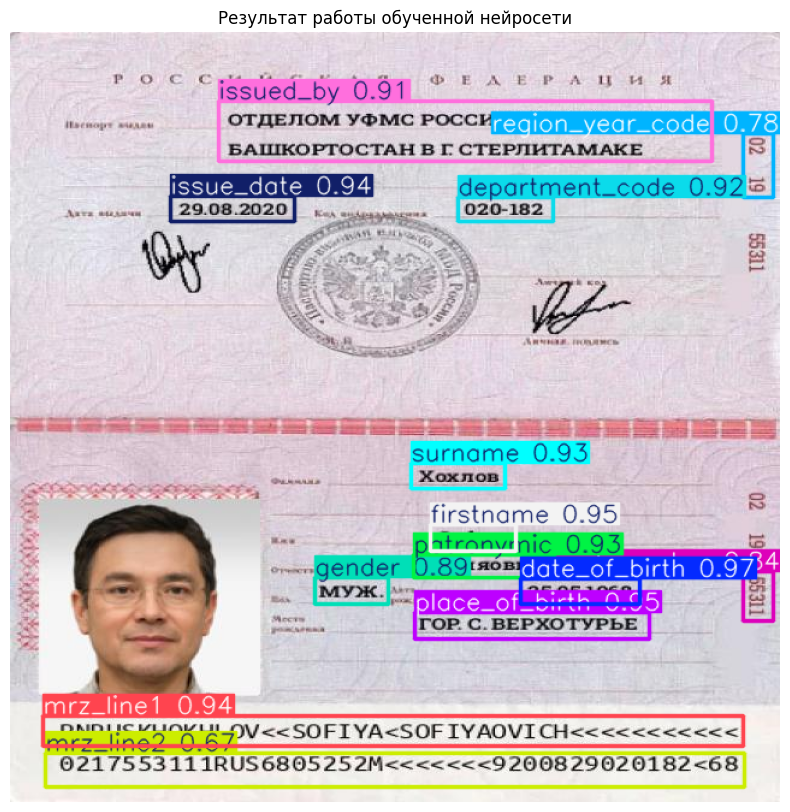

In [7]:
import cv2
import matplotlib.pyplot as plt
import glob
import random
from ultralytics import YOLO

best_model = YOLO('runs/detect/train/weights/best.pt')

test_images = glob.glob("my_passport_dataset/test/images/*.jpg")

if not test_images:
    print("Тестовые изображения не найдены!")
else:
    img_path = random.choice(test_images)
    print(f"Тестируем на изображении: {img_path}")

    prediction_results = best_model.predict(source=img_path, conf=0.5)

    res_plotted = prediction_results[0].plot()

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Результат работы обученной нейросети")
    plt.show()